# Rush Impact

Compares weekday rush-window performance against non-rush periods.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "rush_impact",
    PROJECT_ROOT / "analysis" / "rush-impact.py",
)
rush_impact = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rush_impact)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
RUSH_WINDOWS = ["07:00-09:00", "15:00-18:00"]
INCLUDE_WEEKENDS = False
MIN_OBSERVATIONS = 50
LIMIT = 10

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    rush_window = RUSH_WINDOWS
    include_weekends = INCLUDE_WEEKENDS
    min_observations = MIN_OBSERVATIONS
    limit = LIMIT

df = rush_impact.load_observations(Args)
impact = rush_impact.build_rush_impact(Args, df)
impact

,line_ref,line_name,rush_obs_count,non_rush_obs_count,rush_avg_delay_min,non_rush_avg_delay_min,rush_avg_abs_delay_min,non_rush_avg_abs_delay_min,rush_pct_late,non_rush_pct_late,rush_delay_lift_min,rush_abs_delay_lift_min,rush_late_pct_point_lift
88,901,901,2140.0,7708.0,21.22,-1.56,27.98,23.64,51.96,36.88,22.78,4.35,15.08
112,N11,N11,420.0,948.0,-44.40,-61.87,45.82,66.39,33.33,34.07,17.47,-20.57,-0.74
79,77,77,360.0,402.0,-5.13,-16.61,10.10,18.60,55.83,10.45,11.48,-8.51,45.39
133,V3,V3,379.0,291.0,-2.00,-12.11,2.92,12.80,35.62,33.33,10.10,-9.88,2.29
81,79,79,250.0,390.0,0.44,-9.17,1.74,9.21,31.20,5.90,9.61,-7.47,25.30
53,615,615,680.0,610.0,6.58,-2.49,6.79,5.96,90.88,37.05,9.07,0.83,53.83
44,51A,51A,638.0,1581.0,2.62,-2.83,3.90,3.39,41.22,16.38,5.45,0.52,24.84
51,612,612,438.0,185.0,7.94,2.66,9.04,2.66,76.26,84.32,5.29,6.38,-8.07
47,5A,5A,6232.0,3961.0,-1.01,-5.01,2.01,5.60,36.09,14.77,4.00,-3.58,21.32
121,N8,N8,560.0,746.0,1.89,-1.36,4.78,2.62,56.79,23.59,3.25,2.16,33.19


Text(0, 0.5, 'Line')

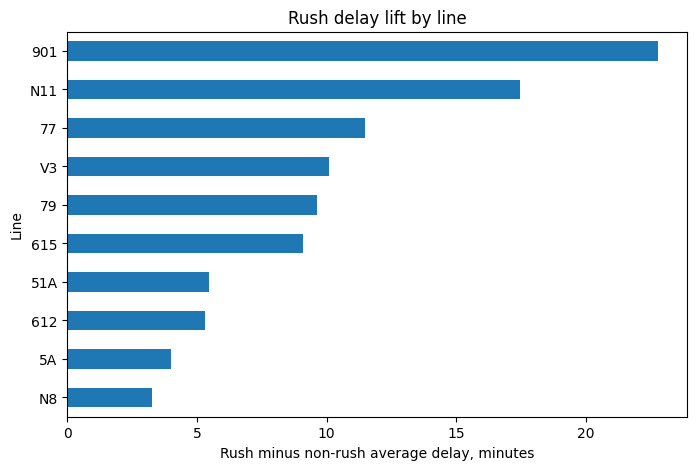

In [3]:
ax = impact.sort_values("rush_delay_lift_min").plot.barh(
    x="line_ref",
    y="rush_delay_lift_min",
    legend=False,
    figsize=(8, 5),
    title="Rush delay lift by line",
)
ax.set_xlabel("Rush minus non-rush average delay, minutes")
ax.set_ylabel("Line")